In [1]:
import numpy as np
import decimal
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.distance import cityblock
import glob
import statistics as st

from apollon.som.som import IncrementalMap
from apollon.som.utilities import best_match

## Prepare features

In [2]:
features = {1:'Spectral Centroid',
           2 : 'Spectral Spread',
           3 :'Spectral Flux',
           4 : 'Roughness',
           5 : 'Sharpness',
           6 : 'SPL',
           7 : 'Correlation Dimension'}

nfeatures = {1 :3,
             2: 6,
             3: 1}
files = list(glob.glob("C:/Sounds/HipHop/Chinese_Hip Hop_44.1/*.csv"))
numfiles = len(files)
numfeatures = len(nfeatures)
lal1 = np.empty((numfiles, numfeatures))
for j, f in enumerate(files):
    la = pd.read_csv(f, index_col=0)
    for i in nfeatures:
        lal1[j][i-1] = la[features[nfeatures[i]]].mean()

In [3]:
files = list(glob.glob("C:/Sounds/HipHop/western_hiphop/*.csv"))
numfiles = len(files)
numfeatures = len(nfeatures)
lbl1 = np.empty((numfiles, numfeatures))
for j, f in enumerate(files):
    la = pd.read_csv(f, index_col=0)
    for i in nfeatures:
        lbl1[j][i-1] = la[features[nfeatures[i]]].mean()

In [5]:
train_X = np.concatenate((lal1,lbl1))
#train_X = lal1
features=numfeatures

In [5]:
target = [('a', i+1) for i in range(1,89)] + [('b', i+1) for i in range(1,89)]

In [6]:
target = [('a', i+1) for i in range(lal1.index.to_list()] + [('b', i+1) for i in lbl1.index.to_list()]

AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [5]:
train_X.shape

(0, 2)

In [264]:
#train_X = np.concatenate((la.to_numpy(), lb.to_numpy()))

NameError: name 'lb' is not defined

## Fit SOM

In [7]:
dx = int(np.sqrt(train_X.shape[0]))+10
dw = train_X.shape[1]
som = IncrementalMap((dx, dx, dw), n_iter=100, eta=0.05, nhr=25)

In [8]:
som.fit(train_X)

ValueError: zero-size array to reduction operation minimum which has no identity

## Results

In [9]:
um = umatrix(som.weights, som.shape, som.metric)
bmu, err = best_match(som.weights, train_X, som.metric)
px, py = np.unravel_index(bmu, som.shape)

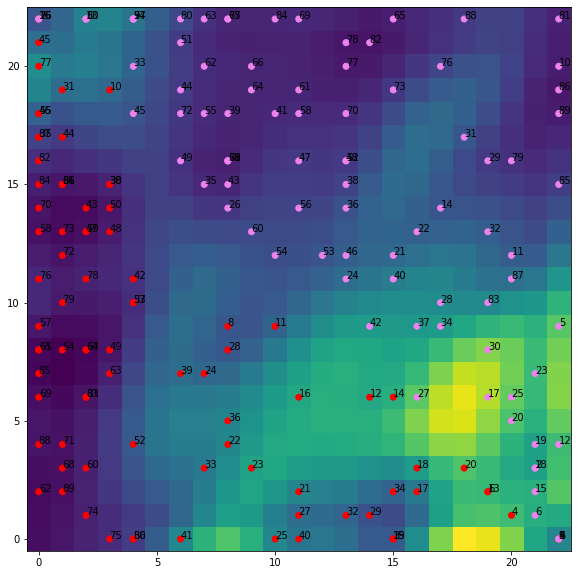

In [10]:
color_map = {'a': 'red', 'b': 'violet'}

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(um, aspect='equal', origin='lower')

ax.scatter(py, px, c=[color_map[t[0]] for t in target])

for t, (y, x) in zip(target, zip(px, py)):
    ax.text(x, y, t[1])

## Component planes

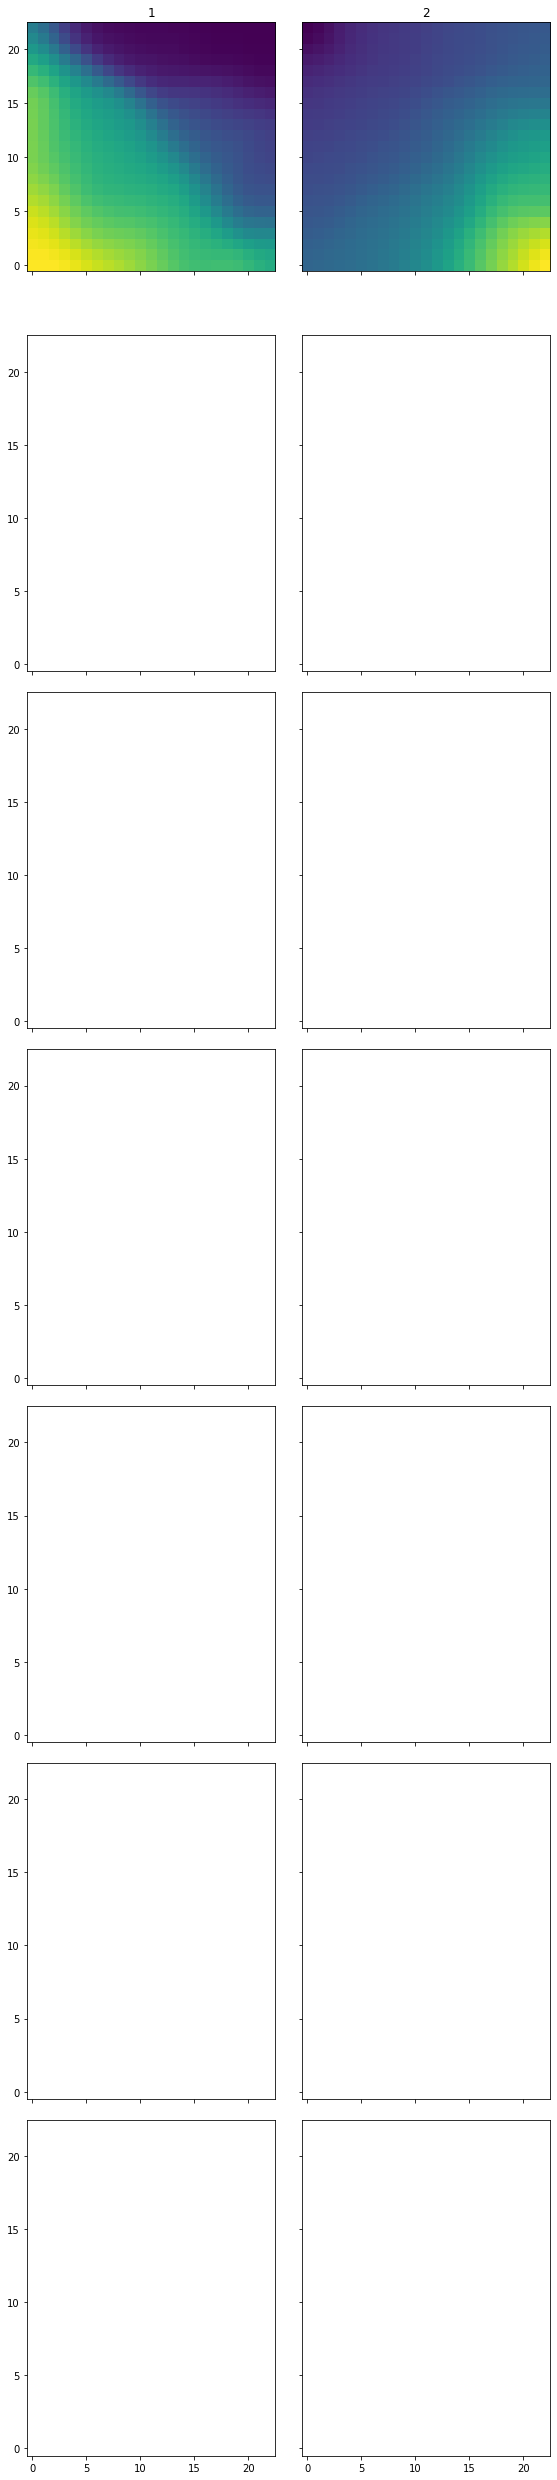

In [458]:
fig, (axs) = plt.subplots(7, 2, figsize=(8, 35), sharex=True, sharey=True)
fig.tight_layout()
for i, (fn, ax) in enumerate(zip(nfeatures, axs.flatten())):
    ax.set_title(fn)
    ax.imshow(som.weights[:, i].reshape(som.shape), origin='lower', aspect='equal')

In [133]:
## Magnitude of weights

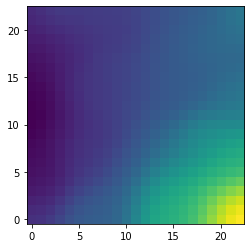

In [134]:
wnorm = np.linalg.norm(som.weights, axis=1)
plt.imshow(wnorm.reshape(som.shape), origin='lower')

## Map distance of unison keys per condition

Plot the map distance between unison keys of each condition agains the key number. Dahsed lines mark pitch class 'C'.

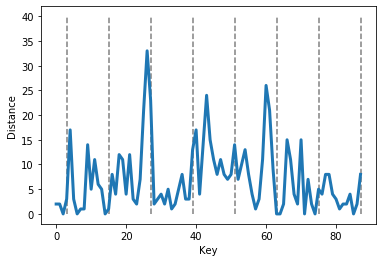

In [112]:
midx = np.dstack((px, py)).squeeze()
d = [cityblock(midx[i], midx[i+88]) for i in range(88)]

fig, ax = plt.subplots(1, 1)
ax.set_xlabel('Key');
ax.set_ylabel('Distance');
ax.vlines(np.arange(3, 88, 12), 0, 40, linestyles='dashed', alpha=.5, zorder=-10)
ax.plot(d, lw=3)